#### [자동차 연비 관련 분석]
---
- 데이터 : auto_mpg.csv
- 특징
    - 1993년도 미국에 자동차 연비 분석을 위해 수집된 데이터
    - 9개의 컬럼 (1개 타겟, 8개 피쳐)
    - 다변량 데이터셋
---

##### [1] 모듈 로딩 및 데이터 준비

In [31]:
# 모듈 로딩
import pandas as pd

In [32]:
# 데이터 준비
DATA_FILE = r"C:\Users\Win11Pro\Desktop\KDT-14\[2]PANDAS\DATA\auto_mpg.csv"

---
##### [2] CSV -> DataFrame 로딩 및 기본 정보 확인

In [33]:
## DF 인스턴스 생성
mpg_df = pd.read_csv(DATA_FILE)

In [34]:
# 기본 요약 정보 확인
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [35]:
# 실제 데이터 확인
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [36]:
# 모든 컬럼의 기초 통계값
mpg_df.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,398,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,NaN,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,NaN,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,NaN,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,NaN,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,NaN,3608.000000,17.175000,79.000000,2.000000,NaN


---
[3] 기초 전처리
- 결측치/중복값 체크
- 컬럼별 자료형 일치

In [37]:
# [3-1] 결측치 : isnull() / isna() -> 원소마다 검사
mpg_df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [38]:
# [3-2] 중복 데이터 검사 : duplicated()
mpg_df.duplicated().sum(0)

np.int64(0)

In [39]:
# [3-3] 컬럼별 자료형 변환
mpg_df['horsepower'].value_counts()['?']

np.int64(6)

In [40]:
# => 이상치 있는 행 번호 추출 제거
drop_idx = mpg_df[mpg_df['horsepower'] == '?'].index
# => 이상치 있는 행 제거
mpg_df = mpg_df.drop(index=drop_idx).reset_index(drop=True)

In [41]:
# 마력 행 정수값으로 형변환
mpg_df['horsepower'] = mpg_df['horsepower'].astype('int32')
# pd.to_numeric(mpg_df['horsepower'])

In [42]:
# [3-3] 컬럼별 자료형 변환 - model year, cylinder, origin 컬럼
# model year, cylinders, origin int64 >>> 범주형
# 고유값
# - 값의 종류
# - Series에 제공되는 메서드 unique()
# 고유값 확인 즉, 컴럼별 값의 종류 체크
for col in ['cylinders','model year','origin']:
    print(f"{col} = {mpg_df[col].unique()}")

cylinders = [8 4 6 3 5]
model year = [70 71 72 73 74 75 76 77 78 79 80 81 82]
origin = [1 3 2]


In [43]:
# int >>> 범주형 형변환
for col in ['cylinders','model year','origin']:
    mpg_df[col] = mpg_df[col].astype('category')
mpg_df.dtypes

mpg              float64
cylinders       category
displacement     float64
horsepower         int32
weight             int64
acceleration     float64
model year      category
origin          category
car name          object
dtype: object

In [49]:
# [3-4] 컬럼별 자료형 변환 - 연속형/수치형 >>> 범주형
# - 숫자값을 일정 구간으로 나누어서 이해가 쉽도록 만들어주는 방법
# - 예) 연령대 : 1,3,6,12 ===> 10대, 20대, 30대 ---> 청년, 중년, 장년, 노년
# - : pandas.cut()
# 마력/출력 => 저출력, 일반출력, 고출력 : 범위 조사
retSR = pd.cut(mpg_df['horsepower'], bins=3,
               labels=['저출력','일반출력','고출력'])

In [48]:
# 현재 데이터 프레임에 추가
mpg_df['hp_label'] = retSR
mpg_df.head

<bound method NDFrame.head of       mpg cylinders  displacement  horsepower  weight  acceleration  \
0    18.0         8         307.0         130    3504          12.0   
1    15.0         8         350.0         165    3693          11.5   
2    18.0         8         318.0         150    3436          11.0   
3    16.0         8         304.0         150    3433          12.0   
4    17.0         8         302.0         140    3449          10.5   
..    ...       ...           ...         ...     ...           ...   
387  27.0         4         140.0          86    2790          15.6   
388  44.0         4          97.0          52    2130          24.6   
389  32.0         4         135.0          84    2295          11.6   
390  28.0         4         120.0          79    2625          18.6   
391  31.0         4         119.0          82    2720          19.4   

    model year origin                   car name hp_label  
0           70      1  chevrolet chevelle malibu     일반출력

---
#### [4] 연비 mpg 컬럼과 관련성이 있는 속성/피쳐
- 타겟 컬럼/속성 : mpg
- 피쳐 컬럼/속성 : 나머지
- 상관계수 활용
    - 컬럼들의 관계/선형 정도를 수치화
    - 값의 범위 : 1 ~ -1
    - 양의 상관관계 / 음의 상관관계
    - 완벽한 선형이 아닌 경우 값이 -1/1에 가까운 값이 나오지 않을 수도 있음
    - 시각화를 통해서 컬럼들을 결정지어야함

In [45]:
# mpg 컬럼과 관련성이 있는 정도 채크: corr()
mpg_df.corr(numeric_only=True)

,mpg,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.805127,-0.778427,-0.832244,0.423329
displacement,-0.805127,1.000000,0.897257,0.932994,-0.543800
horsepower,-0.778427,0.897257,1.000000,0.864538,-0.689196
weight,-0.832244,0.932994,0.864538,1.000000,-0.416839
acceleration,0.423329,-0.543800,-0.689196,-0.416839,1.000000


In [76]:
# mpg 컬럼만 추출
mpg_corr = mpg_df.corr(numeric_only=True)['mpg']

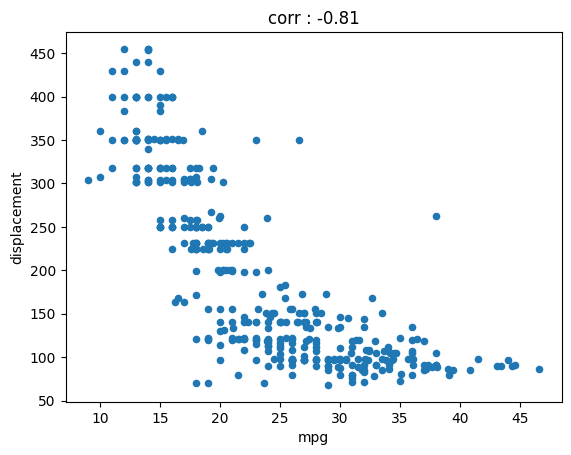

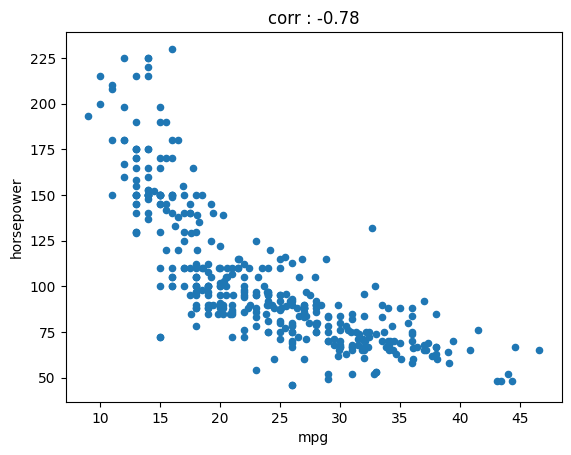

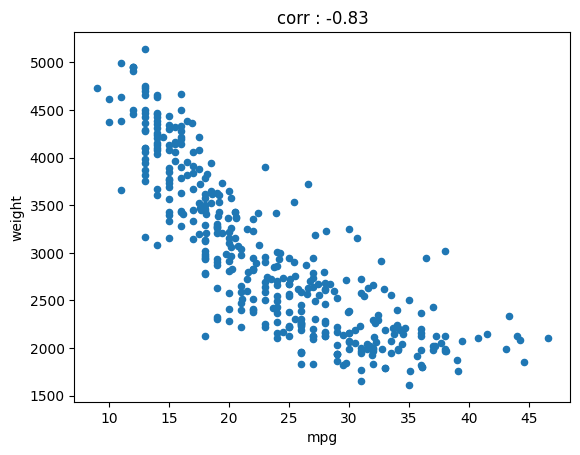

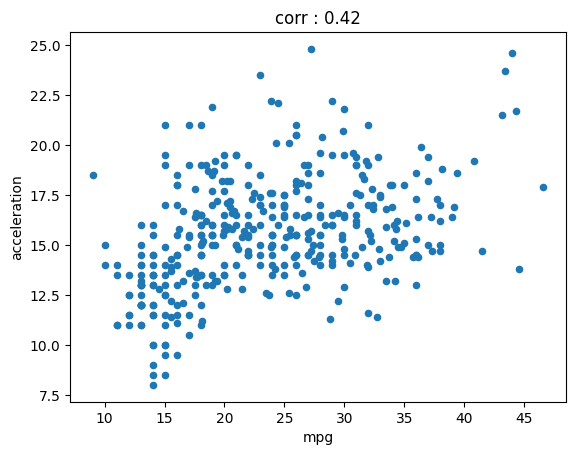

In [80]:
# mpg 컬럼과 다른 컬럼과의 관계 시각화
for col in mpg_corr.index[1:]:
    mpg_df.plot(x='mpg', y=col, kind='scatter', title=f"corr : {mpg_corr[col]:.2f}")